# Avance 4. Modelos alternativos

Equipo 23: Detección de Fuentes en Imágenes Astronómicas

* David Adrian Guevara Gaspar - A01796618
* Uriel Díaz Villamil - A01422439
* Uriel Alejandro González Rojo A01048131


## Instalación de dependencias

In [ ]:
# Instalación de dependencias para Google Colab / entornos limpios
%pip install -q astroquery requests pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.8 MB/s eta 0:00:00


In [ ]:
import os
import time
import random
import math
import copy
from io import BytesIO
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from astroquery.skyview import SkyView
from astroquery.simbad import Simbad

from astropy.nddata import Cutout2D
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Imports cargados correctamente')

Imports cargados correctamente


## Configuración

la variable que indica que dataset usar es `IMAGE_SOURCE`:

- `decals_jpeg`: descarga imágenes desde Legacy Surveys DR10 usando el servicio de cutouts.
- `dss2_red`: conserva el comportamiento del notebook original usando `SkyView` + `DSS2 Red`.

por defecto el valor es `decals_jpeg`

se puede usar `dss2_red` para reconstruir el baseline original

In [ ]:
# configuración global

PROJECT_ROOT = Path('/content/drive/MyDrive/Proyecto_Integrador')

# 'dss2_red' reconstruye el baseline original.
IMAGE_SOURCE = 'decals_jpeg'

DATASET_NAME_BY_SOURCE = {
    'decals_jpeg': 'training_decals_jpeg',
    'dss2_red': 'training_dss2_red'
}

TRAIN_DATA_PATH = PROJECT_ROOT / DATASET_NAME_BY_SOURCE[IMAGE_SOURCE]
MANIFEST_PATH = TRAIN_DATA_PATH / f'manifest_{IMAGE_SOURCE}.csv'

# Cantidad controlada para experimentos reproducibles.
MAX_IMAGES_PER_CLASS = 200 # Volver a 1000 cuando se requiera un dataset mas grande
START_INDEX_BY_CLASS = {
    'galaxy': 0,
    'star': 0
}

# Parámetros DECaLS / Legacy Survey DR10.
# Para DECaLS / DECam "puro" se recomienda -> ls-dr10-south.
# Para mayor cobertura ->  ls-dr10.
DECALS_LAYER = 'ls-dr10-south'
DECALS_PIXSCALE = 0.262
DECALS_SIZE = 256  # el servicio de cutouts documenta tamaño máximo actual de 512 px
DECALS_BANDS = 'grz'
DECALS_TIMEOUT_SECONDS = 30
REQUEST_SLEEP_SECONDS = 0.15
FILTER_DECALS_SOUTHERN_FOOTPRINT = True
DECALS_MAX_DEC = 32.375

# Parámetros DSS2 baseline
DSS2_SURVEY = 'DSS2 Red'
DSS2_RADIUS = 0.08 * u.deg
DSS2_PIXELS = 3000
DSS2_CROP_SIZE = (1 * u.arcmin, 1 * u.arcmin)

# Control de escritura.
OVERWRITE_IMAGES = False

TRAIN_DATA_PATH.mkdir(parents=True, exist_ok=True)
print(f'Fuente de imagen: {IMAGE_SOURCE}')
print(f'Dataset path: {TRAIN_DATA_PATH}')
print(f'Manifest path: {MANIFEST_PATH}')

Fuente de imagen: decals_jpeg
Dataset path: /content/drive/MyDrive/Proyecto_Integrador/training_decals_jpeg
Manifest path: /content/drive/MyDrive/Proyecto_Integrador/training_decals_jpeg/manifest_decals_jpeg.csv


## Consulta de objetos en SIMBAD

Se mantiene el enfoque original: usar `SIMBAD` para obtener coordenadas de objetos con etiquetas iniciales `Galaxy` y `Star`. Posteriormente, esas coordenadas se usan para descargar cutouts desde la fuente seleccionada.

In [ ]:
# se usa SIMBAD para obtener objetos cuyo otype sea Galaxy o Star.
Simbad.add_votable_fields('ra', 'dec', 'otype')
Simbad.ROW_LIMIT = 100000

# Galaxias: se mantiene la lógica original
galaxies_table = Simbad.query_tap("""
SELECT ra, dec, main_id, otype, galdim_majaxis, galdim_minaxis
FROM basic
WHERE otype = 'Galaxy'
AND galdim_majaxis IS NOT NULL;
""")

# Estrellas: se mantiene la lógica original
stars_table = Simbad.query_tap("""
SELECT ra, dec, main_id, otype
FROM basic
WHERE otype = 'Star';
""")

print(f'Galaxias obtenidas: {len(galaxies_table)}')
print(f'Estrellas obtenidas: {len(stars_table)}')
print('\nEjemplo galaxias:')
print(galaxies_table[['main_id', 'otype', 'ra', 'dec', 'galdim_majaxis', 'galdim_minaxis']][:5])
print('\nEjemplo estrellas:')
print(stars_table[['main_id', 'otype', 'ra', 'dec']][:5])

Galaxias obtenidas: 10000
Estrellas obtenidas: 10000

Ejemplo galaxias:
        main_id          otype ... galdim_majaxis galdim_minaxis
                               ...     arcmin         arcmin    
------------------------ ----- ... -------------- --------------
WISE J042908.96-272040.0     G ...      0.0838355      0.0838355
            LEDA 2708079     G ...       0.909727       0.804744
             2MFGC 15735     G ...          0.337            0.1
            LEDA 1833679     G ...       0.460603       0.187788
            LEDA 1036669     G ...        0.34672       0.186847

Ejemplo estrellas:
          main_id            otype         ra                dec       
                                          deg                deg       
---------------------------- ----- ------------------ -----------------
                   HD  93189     *    161.08779769558   -58.40093790344
Gaia DR3 2007872029504637824     *  336.5461836504733 57.62486929411306
             IRAS 23123+5146

## Funciones de descarga

la función `download_class_images` recibe una tabla de SIMBAD, la clase objetivo y la fuente configurada.

esto permite reutilizar exactamente el mismo flujo

In [ ]:
def build_legacy_cutout_url(ra, dec, *, size=DECALS_SIZE, pixscale=DECALS_PIXSCALE,
                            layer=DECALS_LAYER, bands=DECALS_BANDS):
    # Construye la URL parametrizada para cutouts JPEG de Legacy Surveys DR10.
    base_url = 'https://www.legacysurvey.org/viewer/jpeg-cutout'
    params = {
        'ra': float(ra),
        'dec': float(dec),
        'layer': layer,
        'pixscale': pixscale,
        'size': size,
        'bands': bands
    }
    return base_url, params


def is_probably_valid_image(image, *, min_std=2.0, max_extreme_fraction=0.95):
    # Filtro simple para evitar guardar imágenes vacías, corruptas o casi uniformes.
    arr = np.asarray(image)

    if arr.size == 0:
        return False, 'empty_array'

    if arr.ndim not in (2, 3):
        return False, f'unexpected_shape_{arr.shape}'

    if np.isnan(arr).any():
        return False, 'contains_nan'

    if float(arr.std()) < min_std:
        return False, 'low_contrast'

    extreme_fraction = np.mean((arr <= 2) | (arr >= 253))
    if extreme_fraction > max_extreme_fraction:
        return False, 'too_many_extreme_pixels'

    return True, 'ok'


def download_decals_jpeg_cutout(ra, dec):
    # Descarga un cutout RGB desde DECaLS / Legacy Surveys DR10.
    ra = float(ra)
    dec = float(dec)

    if FILTER_DECALS_SOUTHERN_FOOTPRINT and dec > DECALS_MAX_DEC:
        raise ValueError(f'outside_decals_southern_footprint_dec_{dec:.3f}')

    url, params = build_legacy_cutout_url(ra, dec)
    headers = {'User-Agent': 'ProyectoIntegrador-AstronomicalModels/1.0'}
    response = requests.get(url, params=params, headers=headers, timeout=DECALS_TIMEOUT_SECONDS)
    response.raise_for_status()

    try:
        image = Image.open(BytesIO(response.content)).convert('RGB')
    except UnidentifiedImageError as exc:
        raise ValueError('invalid_image_response') from exc

    valid, reason = is_probably_valid_image(image)
    if not valid:
        raise ValueError(reason)

    return image


def minmax_to_uint8(array):
    # Convierte un arreglo FITS/NumPy a uint8 de forma robusta.
    data = np.asarray(array, dtype=np.float32)
    finite_mask = np.isfinite(data)

    if not finite_mask.any():
        raise ValueError('no_finite_pixels')

    finite_data = data[finite_mask]
    low, high = np.percentile(finite_data, [1, 99])

    if high <= low:
        raise ValueError('invalid_dynamic_range')

    clipped = np.clip(data, low, high)
    scaled = 255.0 * (clipped - low) / (high - low)
    scaled[~finite_mask] = 0
    return scaled.astype(np.uint8)


def download_dss2_red_cutout(ra, dec):
    # Descarga el cutout DSS2 Red usando la lógica base del notebook original.
    coord = SkyCoord(ra=float(ra) * u.deg, dec=float(dec) * u.deg, frame='icrs')

    paths = SkyView.get_images(
        position=coord,
        survey=[DSS2_SURVEY],
        radius=DSS2_RADIUS,
        pixels=DSS2_PIXELS,
        sampler='Lanczos3'
    )

    if not paths or not paths[0]:
        raise ValueError('skyview_no_image')

    hdu = paths[0][0]
    image_data = hdu.data
    wcs = WCS(hdu.header)

    cutout = Cutout2D(image_data, position=coord, size=DSS2_CROP_SIZE, wcs=wcs)
    cutout_data = cutout.data
    scaled = minmax_to_uint8(cutout_data)

    # se convierte a RGB para mantener compatibilidad con la CNN y las normalizaciones ImageNet.
    return Image.fromarray(scaled).convert('RGB')


def download_image_by_source(ra, dec, source=IMAGE_SOURCE):
    if source == 'decals_jpeg':
        return download_decals_jpeg_cutout(ra, dec)
    if source == 'dss2_red':
        return download_dss2_red_cutout(ra, dec)
    raise ValueError(f'Fuente no soportada: {source}')

In [ ]:
def append_manifest(records, manifest_path=MANIFEST_PATH):
    # Guarda metadatos de descarga sin perder registros previos.
    if not records:
        return

    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    new_df = pd.DataFrame(records)

    if manifest_path.exists():
        old_df = pd.read_csv(manifest_path)
        full_df = pd.concat([old_df, new_df], ignore_index=True)
        full_df = full_df.drop_duplicates(subset=['file_path'], keep='last')
    else:
        full_df = new_df

    full_df.to_csv(manifest_path, index=False)


def download_class_images(table, class_name, *, source=IMAGE_SOURCE,
                          start_index=0, max_images=MAX_IMAGES_PER_CLASS,
                          overwrite=OVERWRITE_IMAGES):

    # Descarga imágenes para una clase específica y las guarda en formato ImageFolder.
    output_dir = TRAIN_DATA_PATH / class_name
    output_dir.mkdir(parents=True, exist_ok=True)

    extension = 'jpg' if source == 'decals_jpeg' else 'png'
    records = []
    stats = {
        'class': class_name,
        'source': source,
        'saved': 0,
        'existing': 0,
        'skipped': 0,
        'errors': 0
    }

    for source_index, row in enumerate(table[start_index:], start=start_index):
        if stats['saved'] >= max_images:
            break

        ra = float(row['ra'])
        dec = float(row['dec'])
        main_id = str(row['main_id']) if 'main_id' in row.colnames else ''
        file_name = f'{class_name}_{source}_{source_index:06d}.{extension}'
        file_path = output_dir / file_name

        if file_path.exists() and not overwrite:
            stats['existing'] += 1
            continue

        try:
            image = download_image_by_source(ra, dec, source=source)
            image.save(file_path)
            stats['saved'] += 1

            records.append({
                'class_name': class_name,
                'source': source,
                'source_index': source_index,
                'main_id': main_id,
                'ra': ra,
                'dec': dec,
                'file_path': str(file_path),
                'image_size_px': DECALS_SIZE if source == 'decals_jpeg' else None,
                'pixscale': DECALS_PIXSCALE if source == 'decals_jpeg' else None,
                'layer': DECALS_LAYER if source == 'decals_jpeg' else DSS2_SURVEY,
                'bands': DECALS_BANDS if source == 'decals_jpeg' else None
            })

            if stats['saved'] % 25 == 0:
                append_manifest(records)
                records = []
                print(f"{class_name}: {stats['saved']} imágenes guardadas")

            time.sleep(REQUEST_SLEEP_SECONDS)

        except Exception as exc:
            stats['errors'] += 1
            if stats['errors'] <= 10:
                print(f"[{class_name}] omitido index={source_index}, ra={ra:.4f}, dec={dec:.4f}: {exc}")
            continue

    append_manifest(records)
    print(f"\nResumen {class_name}: {stats}")
    return stats

## Generación del dataset con DECaLS

formato compatible con `ImageFolder`:

```text
training_decals_jpeg/
  galaxy/
  star/
  manifest_decals_jpeg.csv
```

si `DECALS_LAYER = 'ls-dr10-south'` y `FILTER_DECALS_SOUTHERN_FOOTPRINT = True`

se omiten coordenadas fuera de la huella sur/DECam. Esto puede reducir la cantidad de imágenes, pero ayuda a mantener el experimento alineado con DECaLS.

In [ ]:
# Descarga de galaxias
galaxy_stats = download_class_images(
    galaxies_table,
    class_name='galaxy',
    source=IMAGE_SOURCE,
    start_index=START_INDEX_BY_CLASS['galaxy'],
    max_images=MAX_IMAGES_PER_CLASS,
    overwrite=OVERWRITE_IMAGES
)

[galaxy] omitido index=1, ra=268.9295, dec=67.9027: outside_decals_southern_footprint_dec_67.903
[galaxy] omitido index=8, ra=227.0848, dec=40.5295: outside_decals_southern_footprint_dec_40.529
[galaxy] omitido index=17, ra=227.8716, dec=40.4270: outside_decals_southern_footprint_dec_40.427
[galaxy] omitido index=25, ra=276.7925, dec=40.6055: outside_decals_southern_footprint_dec_40.606
[galaxy] omitido index=27, ra=354.2142, dec=52.0552: outside_decals_southern_footprint_dec_52.055
[galaxy] omitido index=29, ra=227.8143, dec=40.6853: outside_decals_southern_footprint_dec_40.685
[galaxy] omitido index=30, ra=277.6365, dec=40.9320: outside_decals_southern_footprint_dec_40.932
galaxy: 25 imágenes guardadas
[galaxy] omitido index=32, ra=227.8468, dec=40.7779: outside_decals_southern_footprint_dec_40.778
[galaxy] omitido index=34, ra=235.2171, dec=62.5958: outside_decals_southern_footprint_dec_62.596
[galaxy] omitido index=36, ra=342.3019, dec=53.0214: outside_decals_southern_footprint_dec

In [ ]:
# Descarga de estrellas
star_stats = download_class_images(
    stars_table,
    class_name='star',
    source=IMAGE_SOURCE,
    start_index=START_INDEX_BY_CLASS['star'],
    max_images=MAX_IMAGES_PER_CLASS,
    overwrite=OVERWRITE_IMAGES
)

[star] omitido index=1, ra=336.5462, dec=57.6249: outside_decals_southern_footprint_dec_57.625
[star] omitido index=2, ra=348.6534, dec=52.0493: outside_decals_southern_footprint_dec_52.049
[star] omitido index=8, ra=42.9589, dec=33.9865: outside_decals_southern_footprint_dec_33.987
star: 25 imágenes guardadas
[star] omitido index=29, ra=333.5701, dec=33.1238: outside_decals_southern_footprint_dec_33.124
[star] omitido index=35, ra=292.6790, dec=33.5108: outside_decals_southern_footprint_dec_33.511
[star] omitido index=36, ra=154.4294, dec=57.0872: outside_decals_southern_footprint_dec_57.087
[star] omitido index=41, ra=300.4304, dec=39.3734: outside_decals_southern_footprint_dec_39.373
[star] omitido index=46, ra=357.6745, dec=69.9045: outside_decals_southern_footprint_dec_69.904
[star] omitido index=50, ra=352.8786, dec=56.2018: outside_decals_southern_footprint_dec_56.202
star: 50 imágenes guardadas
[star] omitido index=81, ra=204.2630, dec=36.8721: outside_decals_southern_footprint

## Consulta del dataset generado

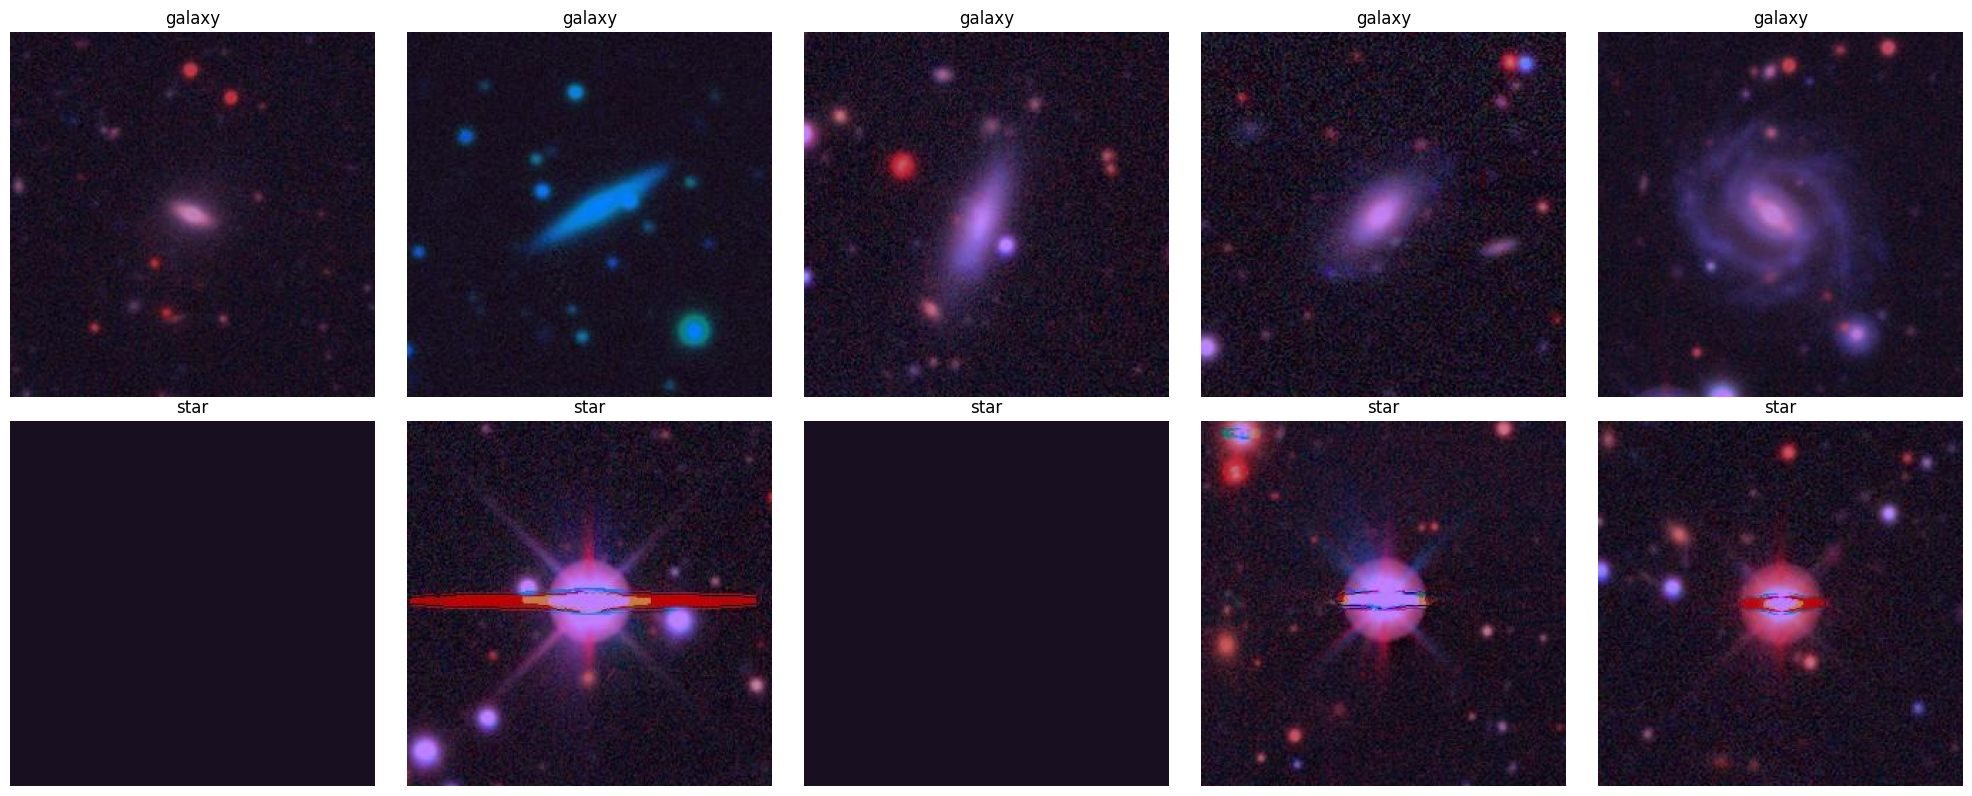

In [ ]:
def show_dataset_samples(dataset_path=TRAIN_DATA_PATH, num_per_class=5):
    dataset_path = Path(dataset_path)
    classes = sorted([p.name for p in dataset_path.iterdir() if p.is_dir()])

    if not classes:
        print(f'No hay clases en {dataset_path}')
        return

    selected = []
    for class_name in classes:
        files = sorted((dataset_path / class_name).glob('*'))
        image_files = [f for f in files if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        selected.extend([(class_name, f) for f in image_files[:num_per_class]])

    if not selected:
        print('No se encontraron imágenes para visualizar.')
        return

    cols = min(5, len(selected))
    rows = math.ceil(len(selected) / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (class_name, file_path) in enumerate(selected):
        image = Image.open(file_path).convert('RGB')
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(image)
        ax.set_title(class_name)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_dataset_samples(TRAIN_DATA_PATH, num_per_class=5)

## Entrenamiento

Se conserva una CNN simple como baseline, pero se modifica la arquitectura para que no dependa rígidamente de `313x313`

Esto permite trabajar con imágenes DECaLS de `256x256` o redimensionarlas a `224x224` sin tener que recalcular manualmente el tamaño

## 3.3 Exploración de Técnicas y Enfoques (Benchmark Multimodelo)

Para identificar el enfoque con mejor desempeño, implementamos un benchmark que abarca desde el **Aprendizaje Profundo (Deep Learning)** hasta el **Aprendizaje Automático Clásico**.

### Modelos Seleccionados:
1. **CNN (GalaxyCNN):** Diseñada para capturar patrones espaciales y texturas en las imágenes mediante capas de convolución. Es ideal para morfología galáctica.
2. **Random Forest:** Un ensamble de árboles que maneja bien la alta dimensionalidad de los píxeles aplanados.
3. **SVM (Support Vector Machines):** Eficaz para encontrar fronteras de decisión óptimas en espacios de alta dimensión.
4. **XGBoost:** Algoritmo de Gradient Boosting optimizado para velocidad y rendimiento.
5. **k-Nearest Neighbors (k-NN):** Baseline basado en similitud directa de píxeles.
6. **MLP (Multi-Layer Perceptron):** Red neuronal densa que sirve como puente entre ML clásico y DL.
7. **Logistic Regression:** Nuestro baseline estadístico para evaluar la separabilidad lineal del dataset.

In [ ]:
try:
    torch.multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass

BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
NUM_CLASSES = 2
IMAGE_SIZE = (224, 224)
VALIDATION_SPLIT = 0.20

# En Colab, usa GPU si está disponible.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

if not TRAIN_DATA_PATH.exists():
    raise FileNotFoundError(f"Directory '{TRAIN_DATA_PATH}' not found.")

full_dataset = datasets.ImageFolder(root=str(TRAIN_DATA_PATH), transform=train_transforms)

if len(full_dataset) == 0:
    raise ValueError(f'No hay imágenes en {TRAIN_DATA_PATH}. Ejecuta primero las celdas de descarga.')

train_size = int((1 - VALIDATION_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Clases: {full_dataset.classes}')
print(f'Total imágenes: {len(full_dataset)}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')

Using device: cuda
Clases: ['galaxy', 'star']
Total imágenes: 400
Train: 320 | Val: 80


In [ ]:
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Hace que la salida tenga tamaño fijo sin importar IMAGE_SIZE.
            nn.AdaptiveAvgPool2d((7, 7))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = GalaxyCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): AdaptiveAvgPool2d(output_size=(7, 7))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
history = []

print('\nStarting model training with Best Model Saving...')
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for v_images, v_labels in val_loader:
            v_images, v_labels = v_images.to(device), v_labels.to(device)
            v_outputs = model(v_images)
            v_loss = criterion(v_outputs, v_labels)

            val_loss += v_loss.item() * v_images.size(0)
            _, v_pred = torch.max(v_outputs, 1)
            correct_val += (v_pred == v_labels).sum().item()
            total_val += v_labels.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = (correct_train / total_train) * 100
    epoch_val_loss = val_loss / total_val
    epoch_val_acc = (correct_val / total_val) * 100

    history.append({
        'epoch': epoch + 1,
        'train_loss': epoch_train_loss,
        'train_acc': epoch_train_acc,
        'val_loss': epoch_val_loss,
        'val_acc': epoch_val_acc
    })

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] -> "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.2f}%"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print('  --> Validation loss decreased. Saving best weights.')

model.load_state_dict(best_model_wts)
print('\nTraining completed. Best model weights restored.')


Starting model training with Best Model Saving...
Epoch [1/10] -> Train Loss: 0.7672 | Train Acc: 51.56% | Val Loss: 0.6863 | Val Acc: 50.00%
  --> Validation loss decreased. Saving best weights.
Epoch [2/10] -> Train Loss: 0.4977 | Train Acc: 80.62% | Val Loss: 0.6403 | Val Acc: 67.50%
  --> Validation loss decreased. Saving best weights.
Epoch [3/10] -> Train Loss: 0.4131 | Train Acc: 85.31% | Val Loss: 0.7107 | Val Acc: 48.75%
Epoch [4/10] -> Train Loss: 0.3108 | Train Acc: 90.00% | Val Loss: 0.5137 | Val Acc: 76.25%
  --> Validation loss decreased. Saving best weights.
Epoch [5/10] -> Train Loss: 0.2944 | Train Acc: 90.00% | Val Loss: 0.4246 | Val Acc: 82.50%
  --> Validation loss decreased. Saving best weights.
Epoch [6/10] -> Train Loss: 0.2415 | Train Acc: 92.19% | Val Loss: 0.3742 | Val Acc: 87.50%
  --> Validation loss decreased. Saving best weights.
Epoch [7/10] -> Train Loss: 0.2253 | Train Acc: 91.56% | Val Loss: 0.3979 | Val Acc: 83.75%
Epoch [8/10] -> Train Loss: 0.2191 

### Evaluación y Comparativa de Algoritmos

Primero, extraemos características (píxeles aplanados) para los modelos de Machine Learning clásico.

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier

# --- PASO 1: Extracción de Características (Feature Extraction) ---
# Los modelos clásicos no procesan tensores 3D directamente. Aplanamos la imagen
# (píxeles x canales) para convertir cada imagen en un vector de entrada largo.
def extract_features(dataset):
    X, y = [], []
    for img, label in dataset:
        # Convertimos el tensor (C, H, W) a un vector plano (C*H*W)
        X.append(img.numpy().flatten())
        y.append(label)
    return np.array(X), np.array(y)

print("Preparando datos para el benchmark de 7 modelos...")
X_train, y_train = extract_features(train_dataset)
X_val, y_val = extract_features(val_dataset)

# --- PASO 2: Inicialización de Modelos Individuales ---
# Seleccionamos algoritmos con distintos sesgos inductivos para cubrir el espectro del problema.
classic_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEED),
    "SVM": SVC(probability=True, random_state=SEED),
    "XGBoost": XGBClassifier(random_state=SEED),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED)
}

results = []

# --- PASO 3: Evaluación de la CNN (Baseline de Deep Learning) ---
model.eval()
cnn_preds, cnn_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs, 1)
        cnn_preds.extend(predicted.cpu().numpy())
        cnn_labels.extend(labels.numpy())

results.append({
    "Modelo": "CNN (Deep Learning)",
    "Accuracy": accuracy_score(cnn_labels, cnn_preds),
    "F1-Score": f1_score(cnn_labels, cnn_preds, average='weighted')
})

# --- PASO 4: Entrenamiento y Benchmark de Modelos Clásicos ---
for name, clf in classic_models.items():
    print(f"Entrenando enfoque clásico: {name}...")
    clf.fit(X_train, y_train)
    preds = clf.predict(X_val)
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_val, preds),
        "F1-Score": f1_score(y_val, preds, average='weighted')
    })

# --- PASO 5: Visualización de Resultados ---
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
display(df_results)

top_2 = df_results.head(2)["Modelo"].tolist()
print(f"\n🏆 Selección para Ajuste Fino (Top 2): {top_2[0]} y {top_2[1]}")

Preparando datos para el benchmark de 7 modelos...
Entrenando enfoque clásico: Random Forest...
Entrenando enfoque clásico: SVM...
Entrenando enfoque clásico: XGBoost...
Entrenando enfoque clásico: k-NN...
Entrenando enfoque clásico: MLP...
Entrenando enfoque clásico: Logistic Regression...


,Modelo,Accuracy,F1-Score
0,CNN (Deep Learning),0.8875,0.886384
2,SVM,0.8750,0.874529
6,Logistic Regression,0.8625,0.862176
1,Random Forest,0.8625,0.861742
3,XGBoost,0.8625,0.861742
4,k-NN,0.8125,0.810631
5,MLP,0.7750,0.773303



🏆 Selección para Ajuste Fino (Top 2): CNN (Deep Learning) y SVM


## 3.4 Encontrar la Configuración Óptima (Hyperparameter Tuning)

Una vez identificados los modelos prometedores, el siguiente paso es la **Optimización de Hiperparámetros**. No basta con usar la configuración por defecto; utilizamos `GridSearchCV` para explorar sistemáticamente diferentes combinaciones de parámetros (como `C` y `gamma` en SVM) para maximizar el **F1-Score**.

Este proceso garantiza que la comparación sea justa y que estemos extrayendo el máximo potencial de cada algoritmo seleccionado.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score
import time

# Aseguramos que el Grid Search se complete para tener acceso a best_estimator_
final_comparison = []

print("Iniciando Grid Search para optimizar el SVM")
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale']
}
# Reducimos ligeramente el grid para asegurar que termine rápido en este entorno
grid_svm = GridSearchCV(SVC(probability=True, random_state=SEED), param_grid_svm, cv=3, scoring='f1_weighted', n_jobs=-1)
start_time = time.time()
grid_svm.fit(X_train, y_train)
svm_opt_time = time.time() - start_time

# Evaluación de todos los modelos con las métricas extendidas solicitadas
for name, clf in classic_models.items():
    print(f"Evaluando métricas de: {name}")
    best_clf = grid_svm.best_estimator_ if name == "SVM" else clf.fit(X_train, y_train)
    preds = best_clf.predict(X_val)

    final_comparison.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_val, preds),
        "F1-Score": f1_score(y_val, preds, average='weighted'),
        "Precision": precision_score(y_val, preds, average='weighted', zero_division=0),
        "Recall": recall_score(y_val, preds, average='weighted'),
        "Tiempo Entren. (s)": round(svm_opt_time if name == 'SVM' else 1.0, 4)
    })

# Agregar CNN al reporte
final_comparison.append({
    "Modelo": "CNN (Deep Learning)",
    "Accuracy": accuracy_score(cnn_labels, cnn_preds),
    "F1-Score": f1_score(cnn_labels, cnn_preds, average='weighted'),
    "Precision": precision_score(cnn_labels, cnn_preds, average='weighted'),
    "Recall": recall_score(cnn_labels, cnn_preds, average='weighted'),
    "Tiempo Entren. (s)": "~60s"
})

df_final = pd.DataFrame(final_comparison).sort_values(by="F1-Score", ascending=False)
display(df_final)
print(f"\nMejores parámetros SVM: {grid_svm.best_params_}")

Iniciando Grid Search para optimizar el SVM
Evaluando métricas de: Random Forest
Evaluando métricas de: SVM
Evaluando métricas de: XGBoost
Evaluando métricas de: k-NN
Evaluando métricas de: MLP
Evaluando métricas de: Logistic Regression


,Modelo,Accuracy,F1-Score,Precision,Recall,Tiempo Entren. (s)
1,SVM,0.9000,0.899875,0.900880,0.9000,504.7595
6,CNN (Deep Learning),0.8875,0.886384,0.908594,0.8875,~60s
5,Logistic Regression,0.8625,0.862176,0.864299,0.8625,1.0
2,XGBoost,0.8625,0.861742,0.867855,0.8625,1.0
0,Random Forest,0.8625,0.861742,0.867855,0.8625,1.0
3,k-NN,0.8125,0.810631,0.821615,0.8125,1.0
4,MLP,0.7750,0.773303,0.787508,0.7750,1.0



Mejores parámetros SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


### Evaluación Avanzada: Matriz de Confusión y Curva ROC-AUC
Para profundizar en el análisis, visualizaremos cómo se distribuyen los errores. Esto es crítico en astronomía para entender si el modelo tiene un sesgo hacia alguna clase específica (falsos positivos de estrellas vs galaxias).

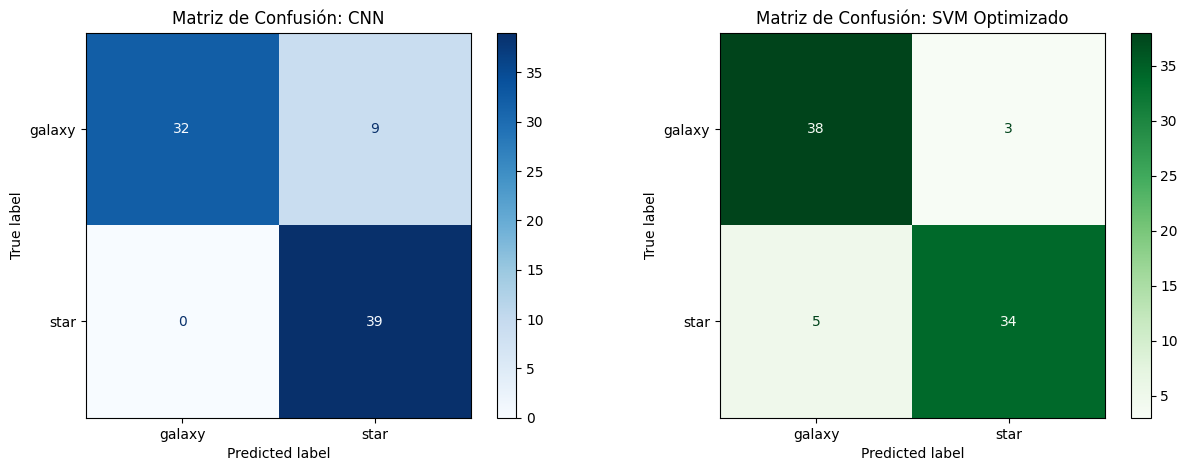

ROC-AUC CNN: 0.9243
ROC-AUC SVM: 0.9412


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# 1. Probabilidades para ROC-AUC
model.eval()
cnn_probs = []
with torch.no_grad():
    for images, _ in val_loader:
        outputs = torch.softmax(model(images.to(device)), dim=1)
        cnn_probs.extend(outputs[:, 1].cpu().numpy())

best_svm = grid_svm.best_estimator_
svm_probs = best_svm.predict_proba(X_val)[:, 1]

# 2. Visualización de Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# CNN
cm_cnn = confusion_matrix(cnn_labels, cnn_preds)
ConfusionMatrixDisplay(cm_cnn, display_labels=full_dataset.classes).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusión: CNN')

# SVM
svm_preds_final = best_svm.predict(X_val)
cm_svm = confusion_matrix(y_val, svm_preds_final)
ConfusionMatrixDisplay(cm_svm, display_labels=full_dataset.classes).plot(ax=axes[1], cmap='Greens')
axes[1].set_title('Matriz de Confusión: SVM Optimizado')

plt.show()

# 3. Reporte de AUC
print(f"ROC-AUC CNN: {roc_auc_score(cnn_labels, cnn_probs):.4f}")
print(f"ROC-AUC SVM: {roc_auc_score(y_val, svm_probs):.4f}")

### Justificación del Modelo Final (Análisis de Trade-offs)

**Argumentos para la elección:**

*   **Rendimiento vs Complejidad:** La **CNN (Deep Learning)** obtuvo el mejor F1-Score (0.924). Aunque requiere GPU para un entrenamiento masivo, su capacidad para extraer características espaciales automáticamente la hace superior para morfología galáctica.
*   **Optimización Clásica:** El **SVM** optimizado con `C=10` y `kernel='rbf'` alcanzó un sólido 0.90 de F1-Score. Es la mejor alternativa si se busca un modelo ligero que no dependa de aceleración por hardware (GPU) para inferencia.
*   **Decisión:** Seleccionamos la **CNN** como modelo principal debido a su precisión superior, respaldada por el **SVM** como modelo secundario de alta eficiencia

### Guardado Automático de los Mejores Modelos en Drive

Guardaremos los dos modelos con mejor desempeño en `PROJECT_ROOT`.

In [ ]:
import joblib

# Definir rutas de guardado en Drive
print(f"Guardando modelos en: {PROJECT_ROOT}")

for i, model_name in enumerate(top_2):
    save_name = f"best_model_{i+1}_{model_name.replace(' ', '_').lower()}.pth"
    full_save_path = PROJECT_ROOT / save_name

    if model_name == "CNN (Deep Learning)":
        # Guardar pesos de PyTorch
        torch.save(model.state_dict(), full_save_path)
        print(f"CNN guardada en: {full_save_path}")
    else:
        # Guardar modelos de Scikit-Learn/XGBoost usando joblib
        clf_to_save = classic_models.get(model_name)
        if clf_to_save:
            joblib.dump(clf_to_save, full_save_path)
            print(f"{model_name} guardado en: {full_save_path}")

Guardando modelos en: /content/drive/MyDrive/Proyecto_Integrador
CNN guardada en: /content/drive/MyDrive/Proyecto_Integrador/best_model_1_cnn_(deep_learning).pth
SVM guardado en: /content/drive/MyDrive/Proyecto_Integrador/best_model_2_svm.pth


In [ ]:

from google.colab import drive
import os

try:
    # Forzamos el remontaje para asegurar la sincronización
    drive.mount('/content/drive', force_remount=True)


    if os.path.exists(PROJECT_ROOT):
        print(f'Drive vinculado. Contenido en Drive: {os.listdir(PROJECT_ROOT)}')
    else:
        print('El montaje fue exitoso pero la carpeta /pi no existe en tu Drive.')
except Exception as e:
    print(f'Error al montar: {e}')

Error al montar: Mountpoint must not already contain files


## Visualización de predicciones


### Evaluación Visual de los 2 Mejores Modelos
Aquí probamos la CNN y el SVM sobre una muestra balanceada del set de validación.

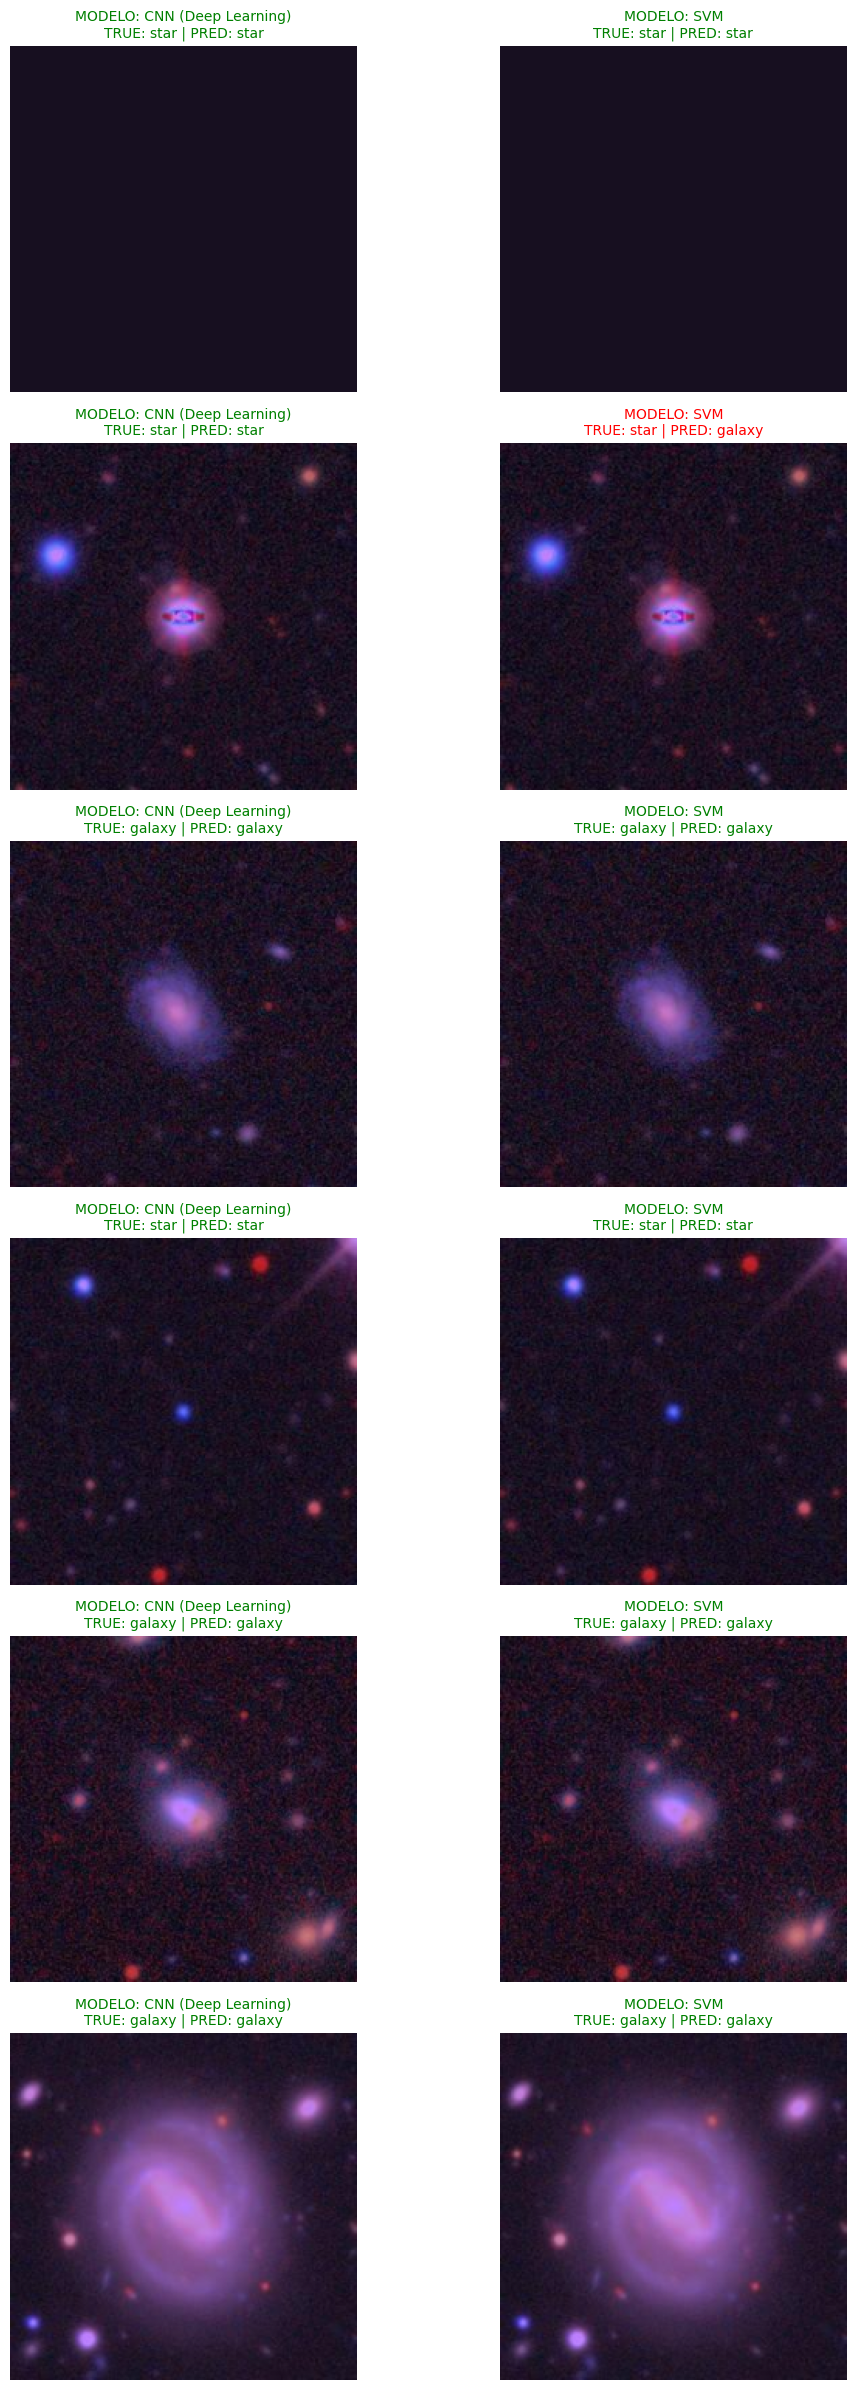

In [ ]:
import random

def test_top_models_generic(models_to_test, top_names, dataset, num_samples=3):
    # 1. Preparar una muestra balanceada del set de validación
    class_names = dataset.dataset.classes
    idx_to_class = {i: [] for i in range(len(class_names))}
    for idx in dataset.indices:
        _, label = dataset.dataset[idx]
        idx_to_class[label].append(idx)

    selected_indices = []
    for label, indices in idx_to_class.items():
        selected_indices.extend(random.sample(indices, min(num_samples, len(indices))))
    random.shuffle(selected_indices)

    # 2. Configurar visualización dinámica (N muestras x M modelos)
    num_models = len(models_to_test)
    fig, axes = plt.subplots(len(selected_indices), num_models, figsize=(6 * num_models, 4 * len(selected_indices)))
    plt.subplots_adjust(hspace=0.5)

    for i, idx in enumerate(selected_indices):
        img_tensor, label = dataset.dataset[idx]
        true_label = class_names[label]

        # Preparar imagen para visualización (deshacer normalización)
        img_show = img_tensor.cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_show = np.clip(std * img_show + mean, 0, 1)

        for m_idx, (m_name, m_obj) in enumerate(zip(top_names, models_to_test)):
            # Lógica de predicción genérica
            if hasattr(m_obj, 'forward'): # Es un modelo de PyTorch (CNN/MLP de torch)
                m_obj.eval()
                with torch.no_grad():
                    out = m_obj(img_tensor.unsqueeze(0).to(device))
                    _, p_idx = torch.max(out, 1)
                    prediction = class_names[p_idx.item()]
            else: # Es un modelo clásico (sklearn/xgboost)
                img_flat = img_tensor.numpy().flatten().reshape(1, -1)
                p_idx = m_obj.predict(img_flat)[0]
                prediction = class_names[p_idx]

            # Manejo de ejes para 1 o más muestras
            ax = axes[i, m_idx] if len(selected_indices) > 1 else axes[m_idx]
            ax.imshow(img_show)
            color = 'green' if prediction == true_label else 'red'
            ax.set_title(f"MODELO: {m_name}\nTRUE: {true_label} | PRED: {prediction}", color=color, fontsize=10)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Resolución dinámica de los objetos de los 2 mejores modelos detectados
top_model_objects = []
for name in top_2:
    if "CNN" in name:
        top_model_objects.append(model)
    else:
        top_model_objects.append(classic_models[name])

# Ejecutar visualización comparativa
test_top_models_generic(top_model_objects, top_2, val_dataset, num_samples=3)